In [1]:
%pip install captum
!git clone https://github.com/kapitan05/causal_calibration.git
%cd causal_calibration
%mkdir -p data

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 12.0 MB/s eta 0:00:00
Cloning into 'causal_calibration'...
remote: Enumerating objects: 207, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 207 (delta 0), reused 1 (delta 0), pack-reused 201 (from 2)
Receiving objects: 100% (207/207), 73.43 MiB | 28.69 MiB/s, done.
Resolving deltas: 100% (122/122), done.
/content/causal_calibration


In [2]:
import random

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from datasets import Image as HFImage
from datasets import load_dataset
from google.colab import userdata
from tqdm import tqdm

from src.attribution import AttributionPipeline
from src.calibration import ReCalXModel, temperature_scaling
from src.causal_tests import evaluate_causal_metric
from src.generators import BucketDeletionGenerator, TopNDeletionGenerator
from src.metrics import calculate_ece, calculate_tace
from src.models import get_preprocessing_transforms

In [ ]:
def normalize_saliency(sal: np.ndarray) -> np.ndarray:
    sal = np.maximum(sal, 0)
    return (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)


def denormalize(tensor: torch.Tensor) -> np.ndarray:
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    return np.clip(img * std + mean, 0, 1)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Raw logits — required for temperature scaling and ReCalXModel
raw_model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT).to(device).eval()
for p in raw_model.parameters():
    p.requires_grad = False

# With softmax — used only for top-1 class selection
model_softmax = nn.Sequential(raw_model, nn.Softmax(dim=1)).eval()


def get_top1(tensor: torch.Tensor) -> int:
    with torch.no_grad():
        return int(torch.argmax(model_softmax(tensor.to(device))).item())


print("ResNet50 loaded.")

Device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 139MB/s]


ResNet50 loaded.


In [5]:
# Same code path used by collect_logits_for_calibration in src/calibration.py
pipeline = AttributionPipeline(raw_model)
print("AttributionPipeline ready.")

Generating filters: 100%|██████████| 5000/5000 [00:19<00:00, 255.02it/s]


AttributionPipeline ready.


In [ ]:
k = userdata.get("HF_TOKEN")
!wget -q --header="Authorization: Bearer {k}" \
  "https://huggingface.co/datasets/ILSVRC/imagenet-1k/resolve/main/data/train-00000-of-00294.parquet"

hf_dataset = load_dataset(
    "parquet", data_files="train-00000-of-00294.parquet", split="train"
)
hf_dataset = hf_dataset.cast_column("image", HFImage())
print(f"Loaded {len(hf_dataset)} images.")

Generating train split: 0 examples [00:00, ? examples/s]

Loaded 4358 images.


In [ ]:
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

preprocess = get_preprocessing_transforms()
indices = random.sample(range(len(hf_dataset)), 20)
selected = hf_dataset.select(indices)

samples = []
for item in tqdm(selected, desc="Loading images"):
    pil_img = item["image"].convert("RGB")
    tensor = preprocess(pil_img).unsqueeze(0)  # (1, 3, 224, 224)
    samples.append((pil_img, tensor))

img_batch = torch.cat([t for _, t in samples], dim=0)  # (20, 3, 224, 224)
target_classes = [get_top1(t) for _, t in samples]

print(f"img_batch: {img_batch.shape}")
print(f"Target classes: {target_classes}")

Loading images: 100%|██████████| 20/20 [00:00<00:00, 83.93it/s]


img_batch: torch.Size([20, 3, 224, 224])
Target classes: [194, 871, 106, 88, 578, 975, 207, 665, 669, 234, 726, 118, 920, 138, 944, 717, 715, 455, 9, 796]


In [ ]:
rise_sals = []
for i, (_, tensor) in enumerate(tqdm(samples, desc="RISE saliency")):
    sal = pipeline.generate_map(tensor, target_classes[i], "rise").numpy()  # (224, 224)
    rise_sals.append(sal)

rise_sal_batch = np.stack(rise_sals)  # (20, 224, 224)
print(f"rise_sal_batch: {rise_sal_batch.shape}")

RISE saliency: 100%|██████████| 20/20 [05:10<00:00, 15.52s/it]

rise_sal_batch: (20, 224, 224)


## Section 2 — Single Image Deep-Dive

Walk through one image in detail: build a deletion sequence, run both the raw and calibrated model, and inspect the fitted temperatures and confidence curves.

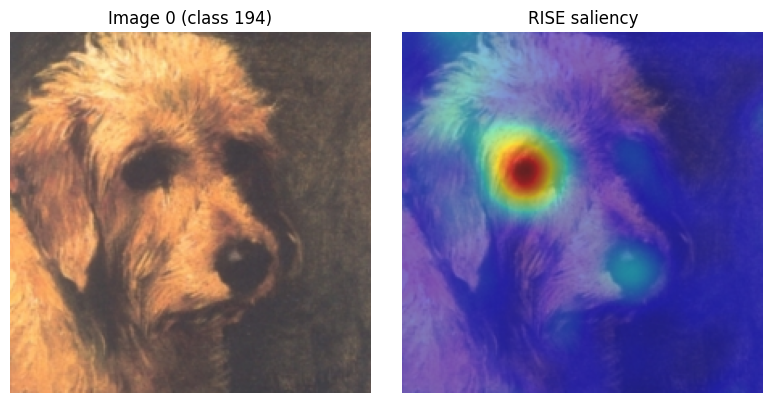

Sequence shape : torch.Size([26, 3, 224, 224])
Levels (first5): ['0.00', '0.04', '0.08', '0.12', '0.16'] ...


In [ ]:
IMG_IDX = 0
single_tensor = img_batch[IMG_IDX : IMG_IDX + 1]  # (1, 3, 224, 224)
target_class = target_classes[IMG_IDX]

sal_norm = normalize_saliency(rise_sals[IMG_IDX])  # [0, 1]
sal_tensor = torch.from_numpy(sal_norm)

gen_del = BucketDeletionGenerator(num_buckets=25)
seq_del, lvl_del = gen_del(single_tensor.cpu(), sal_tensor)

# Visualise original image + saliency overlay
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(denormalize(single_tensor))
ax1.axis("off")
ax1.set_title(f"Image {IMG_IDX} (class {target_class})")
ax2.imshow(denormalize(single_tensor))
ax2.imshow(sal_norm, cmap="jet", alpha=0.5)
ax2.axis("off")
ax2.set_title("RISE saliency")
plt.tight_layout()
plt.show()

print(f"Sequence shape : {seq_del.shape}")
print(f"Levels (first5): {[f'{l:.2f}' for l in lvl_del[:5]]} ...")

In [10]:
raw_probs, raw_auc, raw_all_probs = evaluate_causal_metric(
    raw_model, seq_del.to(device), lvl_del, target_class
)
print(f"Raw model | AUC: {raw_auc:.4f} | Initial confidence: {raw_probs[0]:.4f}")

Raw model | AUC: 0.0456 | Initial confidence: 0.5124


In [ ]:
NUM_BINS = 10

logits_bins = {b: [] for b in range(NUM_BINS)}
labels_bins = {b: [] for b in range(NUM_BINS)}

with torch.no_grad():
    raw_logits_all = raw_model(seq_del.to(device)).cpu().numpy()  # (26, 1000)

for step_idx, logits in enumerate(raw_logits_all):
    level = lvl_del[step_idx]
    bin_idx = min(int(level * NUM_BINS), NUM_BINS - 1)
    logits_bins[bin_idx].append(logits)
    labels_bins[bin_idx].append(target_class)

learned_temps_single = []
for b in range(NUM_BINS):
    lgt = logits_bins[b]
    lbl = labels_bins[b]
    if len(lgt) > 1:
        T = temperature_scaling(np.stack(lgt), np.array(lbl, dtype=np.int64))
    else:
        T = 1.0
    learned_temps_single.append(round(T, 4))

print(f"{'Bin':>4}  {'Level range':>12}  {'Samples':>8}  {'T':>8}")
print("-" * 40)
for b, T in enumerate(learned_temps_single):
    lo, hi = b / NUM_BINS, (b + 1) / NUM_BINS
    n = len(logits_bins[b])
    print(f"{b:>4}  {lo:.1f}–{hi:.1f}        {n:>8}  {T:>8.4f}")

 Bin   Level range   Samples         T
----------------------------------------
   0  0.0–0.1               3    0.0500
   1  0.1–0.2               3    0.5618
   2  0.2–0.3               2    1.1690
   3  0.3–0.4               3    1.2978
   4  0.4–0.5               2    0.9213
   5  0.5–0.6               3    1.8293
   6  0.6–0.7               2    5.0000
   7  0.7–0.8               3    5.0000
   8  0.8–0.9               2    5.0000
   9  0.9–1.0               3    5.0000


In [12]:
recalx_single = ReCalXModel(raw_model, num_bins=NUM_BINS)
recalx_single.load_learned_temperatures(learned_temps_single)
recalx_single = recalx_single.to(device)
cal_probs, cal_auc, cal_all_probs = evaluate_causal_metric(
    recalx_single, seq_del.to(device), lvl_del, target_class
)
print(f"Calibrated model | AUC: {cal_auc:.4f} | Initial confidence: {cal_probs[0]:.4f}")

Calibrated model | AUC: 0.1206 | Initial confidence: 1.0000


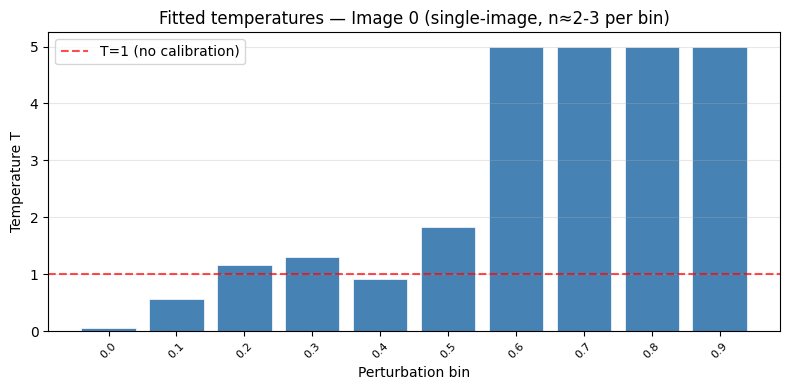

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
bins_x = np.arange(NUM_BINS)
ax.bar(
    bins_x, learned_temps_single, color="steelblue", edgecolor="white", linewidth=0.5
)
ax.axhline(1.0, color="red", linestyle="--", alpha=0.7, label="T=1 (no calibration)")
ax.set_xlabel("Perturbation bin")
ax.set_ylabel("Temperature T")
ax.set_title(f"Fitted temperatures — Image {IMG_IDX} (single-image, n≈2-3 per bin)")
ax.set_xticks(bins_x)
ax.set_xticklabels(
    [f"{b / NUM_BINS:.1f}" for b in range(NUM_BINS)], rotation=45, fontsize=8
)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

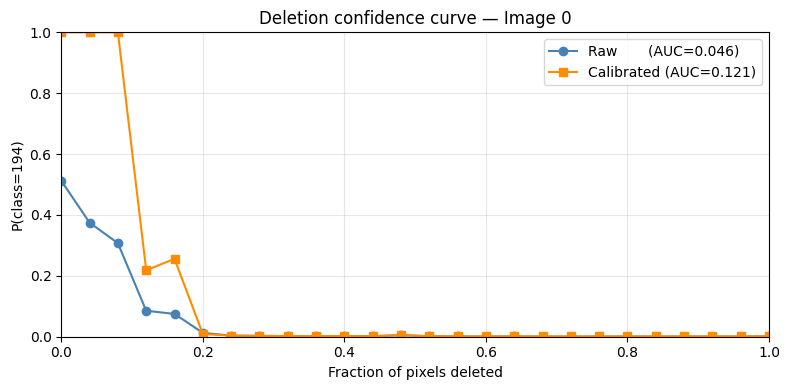

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(
    lvl_del, raw_probs, "o-", color="steelblue", label=f"Raw       (AUC={raw_auc:.3f})"
)
ax.plot(
    lvl_del,
    cal_probs,
    "s-",
    color="darkorange",
    label=f"Calibrated (AUC={cal_auc:.3f})",
)
ax.set_xlabel("Fraction of pixels deleted")
ax.set_ylabel(f"P(class={target_class})")
ax.set_title(f"Deletion confidence curve — Image {IMG_IDX}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

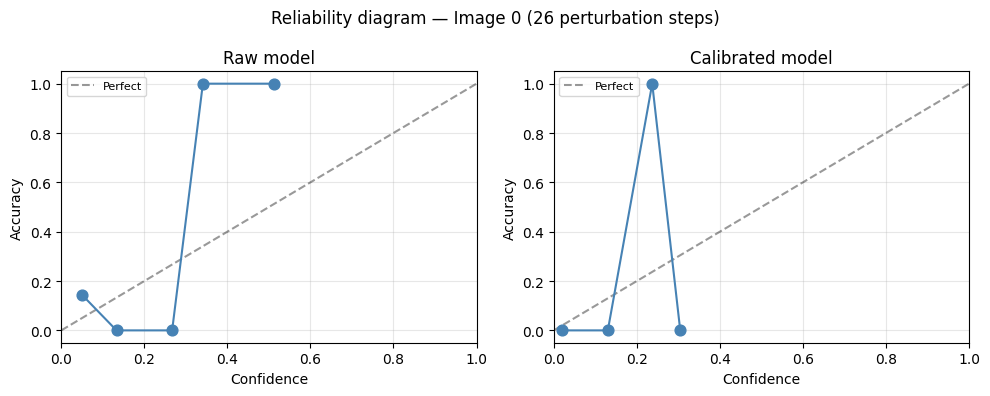

In [ ]:
labels_single = np.full(len(lvl_del), target_class, dtype=np.int64)


def plot_reliability(
    ax, probs_np: np.ndarray, labels_np: np.ndarray, title: str
) -> None:
    confs = np.max(probs_np, axis=1)
    preds = np.argmax(probs_np, axis=1)
    accs = (preds == labels_np).astype(float)
    bins = np.linspace(0, 1, 11)
    bin_confs, bin_accs = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (confs >= lo) & (confs < hi)
        if mask.sum() > 0:
            bin_confs.append(confs[mask].mean())
            bin_accs.append(accs[mask].mean())
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfect")
    ax.scatter(bin_confs, bin_accs, color="steelblue", s=60, zorder=5)
    if bin_confs:
        ax.plot(bin_confs, bin_accs, color="steelblue")
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plot_reliability(ax1, raw_all_probs, labels_single, "Raw model")
plot_reliability(ax2, cal_all_probs, labels_single, "Calibrated model")
plt.suptitle(
    f"Reliability diagram — Image {IMG_IDX} (26 perturbation steps)", fontsize=12
)
plt.tight_layout()
plt.show()

In [ ]:
ece_raw = calculate_ece(raw_all_probs, labels_single)
ece_cal = calculate_ece(cal_all_probs, labels_single)
tace_raw = calculate_tace(raw_all_probs, labels_single)
tace_cal = calculate_tace(cal_all_probs, labels_single)

print(f"{'Metric':<8} {'Raw':>10} {'Calibrated':>12} {'Delta':>10}")
print("-" * 44)
print(f"{'ECE':<8} {ece_raw:>10.4f} {ece_cal:>12.4f} {ece_cal - ece_raw:>+10.4f}")
print(f"{'TACE':<8} {tace_raw:>10.4f} {tace_cal:>12.4f} {tace_cal - tace_raw:>+10.4f}")
print("\nNegative delta = improvement (lower ECE/TACE is better)")
print(
    "Note: single-image calibration overfits — Section 3 gives a more meaningful estimate."
)

Metric          Raw   Calibrated      Delta
--------------------------------------------
ECE          0.1754       0.0934    -0.0821
TACE         0.2564       0.1593    -0.0971

Negative delta = improvement (lower ECE/TACE is better)
Note: single-image calibration overfits — Section 3 gives a more meaningful estimate.


## Section 3 — Batch Evaluation (20 images)

Fit temperatures from all 20 images jointly, then evaluate per-image ECE/TACE to compute mean ± std.

In [ ]:
batch_logits_bins = {b: [] for b in range(NUM_BINS)}
batch_labels_bins = {b: [] for b in range(NUM_BINS)}

gen_del = BucketDeletionGenerator(num_buckets=25)

for i in tqdm(range(len(samples)), desc="Collecting logits"):
    tensor = img_batch[i : i + 1]
    tc = target_classes[i]
    sal = torch.from_numpy(normalize_saliency(rise_sals[i]))

    seq_del_i, lvl_del_i = gen_del(tensor.cpu(), sal)

    with torch.no_grad():
        step_logits = raw_model(seq_del_i.to(device)).cpu().numpy()  # (26, 1000)

    for step_idx, logits in enumerate(step_logits):
        level = lvl_del_i[step_idx]
        bin_idx = min(int(level * NUM_BINS), NUM_BINS - 1)
        batch_logits_bins[bin_idx].append(logits)
        batch_labels_bins[bin_idx].append(tc)

print(f"\n{'Bin':>4}  {'Level range':>12}  {'Samples':>8}")
print("-" * 30)
for b in range(NUM_BINS):
    lo, hi = b / NUM_BINS, (b + 1) / NUM_BINS
    print(f"{b:>4}  {lo:.1f}–{hi:.1f}        {len(batch_logits_bins[b]):>8}")


 Bin   Level range   Samples
------------------------------
   0  0.0–0.1              60
   1  0.1–0.2              60
   2  0.2–0.3              40
   3  0.3–0.4              60
   4  0.4–0.5              40
   5  0.5–0.6              60
   6  0.6–0.7              40
   7  0.7–0.8              60
   8  0.8–0.9              40
   9  0.9–1.0              60


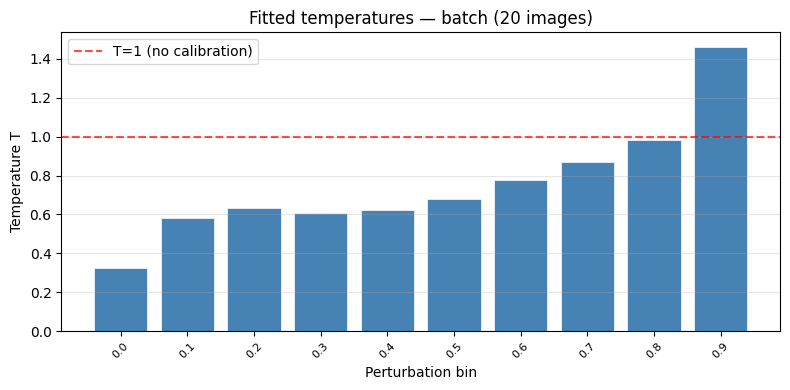

Temperatures: [0.3241, 0.5827, 0.631, 0.6062, 0.6219, 0.6772, 0.7782, 0.8698, 0.9815, 1.4638]


In [ ]:
batch_temps = []
for b in range(NUM_BINS):
    lgt = batch_logits_bins[b]
    lbl = batch_labels_bins[b]
    if len(lgt) > 1:
        T = temperature_scaling(np.stack(lgt), np.array(lbl, dtype=np.int64))
    else:
        T = 1.0
    batch_temps.append(round(T, 4))

global_recalx = ReCalXModel(raw_model, num_bins=NUM_BINS)
global_recalx.load_learned_temperatures(batch_temps)
global_recalx = global_recalx.to(device)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    np.arange(NUM_BINS),
    batch_temps,
    color="steelblue",
    edgecolor="white",
    linewidth=0.5,
)
ax.axhline(1.0, color="red", linestyle="--", alpha=0.7, label="T=1 (no calibration)")
ax.set_xlabel("Perturbation bin")
ax.set_ylabel("Temperature T")
ax.set_title("Fitted temperatures — batch (20 images)")
ax.set_xticks(np.arange(NUM_BINS))
ax.set_xticklabels(
    [f"{b / NUM_BINS:.1f}" for b in range(NUM_BINS)], rotation=45, fontsize=8
)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Temperatures:", batch_temps)

In [ ]:
ece_raws, ece_cals = [], []
tace_raws, tace_cals = [], []

for i in tqdm(range(len(samples)), desc="Evaluating images"):
    tensor = img_batch[i : i + 1]
    tc = target_classes[i]
    sal = torch.from_numpy(normalize_saliency(rise_sals[i]))

    seq_del_i, lvl_del_i = gen_del(tensor.cpu(), sal)
    labels_i = np.full(len(lvl_del_i), tc, dtype=np.int64)

    _, _, raw_ap = evaluate_causal_metric(
        raw_model, seq_del_i.to(device), lvl_del_i, tc
    )
    _, _, cal_ap = evaluate_causal_metric(
        global_recalx, seq_del_i.to(device), lvl_del_i, tc
    )

    ece_raws.append(calculate_ece(raw_ap, labels_i))
    ece_cals.append(calculate_ece(cal_ap, labels_i))
    tace_raws.append(calculate_tace(raw_ap, labels_i))
    tace_cals.append(calculate_tace(cal_ap, labels_i))

print(f"{'Metric':<8} {'Model':>12} {'Mean':>8} {'Std':>8}")
print("-" * 42)
for metric, raws, cals in [("ECE", ece_raws, ece_cals), ("TACE", tace_raws, tace_cals)]:
    print(f"{metric:<8} {'Raw':>12} {np.mean(raws):>8.4f} {np.std(raws):>8.4f}")
    print(f"{metric:<8} {'Calibrated':>12} {np.mean(cals):>8.4f} {np.std(cals):>8.4f}")
    print()

Evaluating images: 100%|██████████| 20/20 [00:03<00:00,  5.47it/s]

Metric          Model     Mean      Std
------------------------------------------
ECE               Raw   0.2716   0.1252
ECE        Calibrated   0.1666   0.1054

TACE              Raw   0.3407   0.1002
TACE       Calibrated   0.1769   0.1279



/tmp/ipykernel_604/4157130324.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(
/tmp/ipykernel_604/4157130324.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bplot = ax.boxplot(


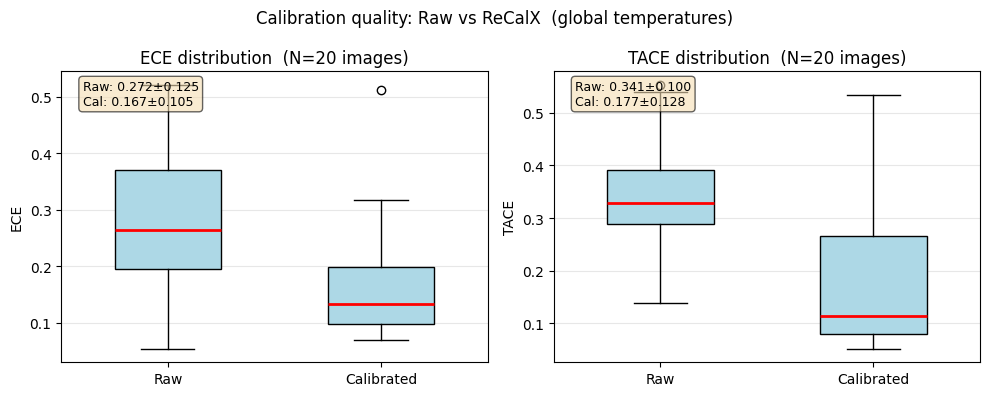

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (vals_raw, vals_cal, metric) in zip(
    axes,
    [
        (ece_raws, ece_cals, "ECE"),
        (tace_raws, tace_cals, "TACE"),
    ],
):
    bplot = ax.boxplot(
        [vals_raw, vals_cal],
        labels=["Raw", "Calibrated"],
        patch_artist=True,
        widths=0.5,
        boxprops=dict(facecolor="lightblue"),
        medianprops=dict(color="red", linewidth=2),
    )
    ax.set_title(f"{metric} distribution  (N=20 images)")
    ax.set_ylabel(metric)
    ax.grid(axis="y", alpha=0.3)
    mr, sr = np.mean(vals_raw), np.std(vals_raw)
    mc, sc = np.mean(vals_cal), np.std(vals_cal)
    ax.text(
        0.05,
        0.97,
        f"Raw: {mr:.3f}±{sr:.3f}\nCal: {mc:.3f}±{sc:.3f}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.6),
    )

plt.suptitle("Calibration quality: Raw vs ReCalX  (global temperatures)", fontsize=12)
plt.tight_layout()
plt.show()

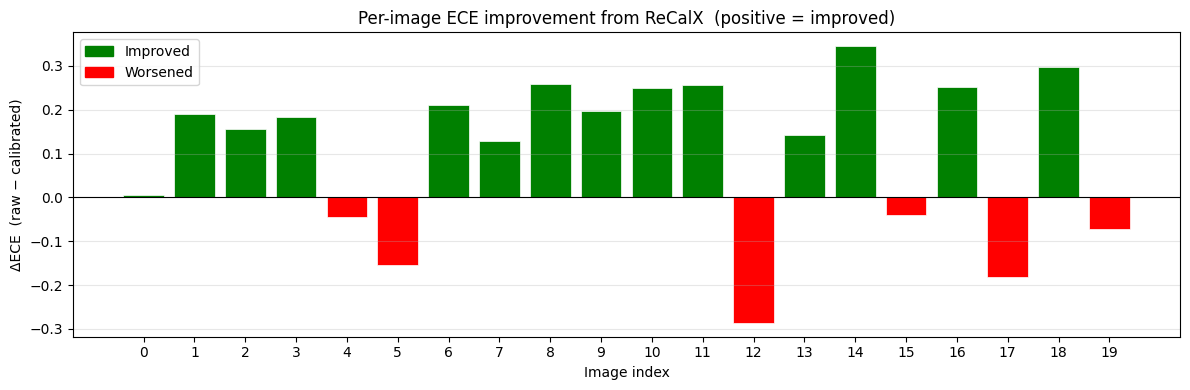

Improved: 14/20  |  Mean ΔECE: +0.1050


In [ ]:
delta_ece = [r - c for r, c in zip(ece_raws, ece_cals)]  # positive = improvement
colors = ["green" if d > 0 else "red" for d in delta_ece]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(delta_ece)), delta_ece, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Image index")
ax.set_ylabel("ΔECE  (raw − calibrated)")
ax.set_title("Per-image ECE improvement from ReCalX  (positive = improved)")
ax.set_xticks(range(len(delta_ece)))
ax.grid(axis="y", alpha=0.3)
ax.legend(
    handles=[
        mpatches.Patch(color="green", label="Improved"),
        mpatches.Patch(color="red", label="Worsened"),
    ]
)
plt.tight_layout()
plt.show()

n_improved = sum(d > 0 for d in delta_ece)
print(
    f"Improved: {n_improved}/{len(delta_ece)}  |  Mean ΔECE: {np.mean(delta_ece):+.4f}"
)

## Section 4 — Normalization Sanity Check

Different attribution methods produce saliency maps with very different value ranges. The bucket generators are rank-based (scale-invariant), so they work regardless, but the raw scale differences explain why some methods look broken when visualised without normalization.

In [ ]:
methods = ["rise", "ig", "saliency", "gradientshap", "occlusion", "feature_ablation"]
method_labels = {
    "rise": "RISE",
    "ig": "IntegratedGradients",
    "saliency": "Saliency",
    "gradientshap": "GradientShap",
    "occlusion": "Occlusion",
    "feature_ablation": "FeatureAblation",
}

saliency_maps = {}
for method in tqdm(methods, desc="Running attributions"):
    sal = (
        pipeline.generate_map(single_tensor.to(device), target_class, method)
        .cpu()
        .numpy()
    )
    saliency_maps[method] = sal

print(
    f"\n{'Method':<22} {'Raw min':>10} {'Raw max':>10} {'Norm min':>10} {'Norm max':>10}"
)
print("-" * 66)
for m, sal in saliency_maps.items():
    sal_n = normalize_saliency(sal)
    print(
        f"{method_labels[m]:<22} {sal.min():>10.4f} {sal.max():>10.4f} {sal_n.min():>10.4f} {sal_n.max():>10.4f}"
    )

print(
    "\nNote: BucketDeletionGenerator uses argsort → rank-invariant, scale does not matter."
)

Running attributions: 100%|██████████| 6/6 [05:12<00:00, 52.10s/it]


Method                    Raw min    Raw max   Norm min   Norm max
------------------------------------------------------------------
RISE                       0.1699     1.1893     0.0000     1.0000
IntegratedGradients       -1.0137     1.1442     0.0000     1.0000
Saliency                   0.0003     0.7415     0.0000     1.0000
GradientShap              -1.3398     1.5222     0.0000     1.0000
Occlusion                 -0.5251     1.2610     0.0000     1.0000
FeatureAblation           -1.1604     1.4739     0.0000     1.0000

Note: BucketDeletionGenerator uses argsort → rank-invariant, scale does not matter.


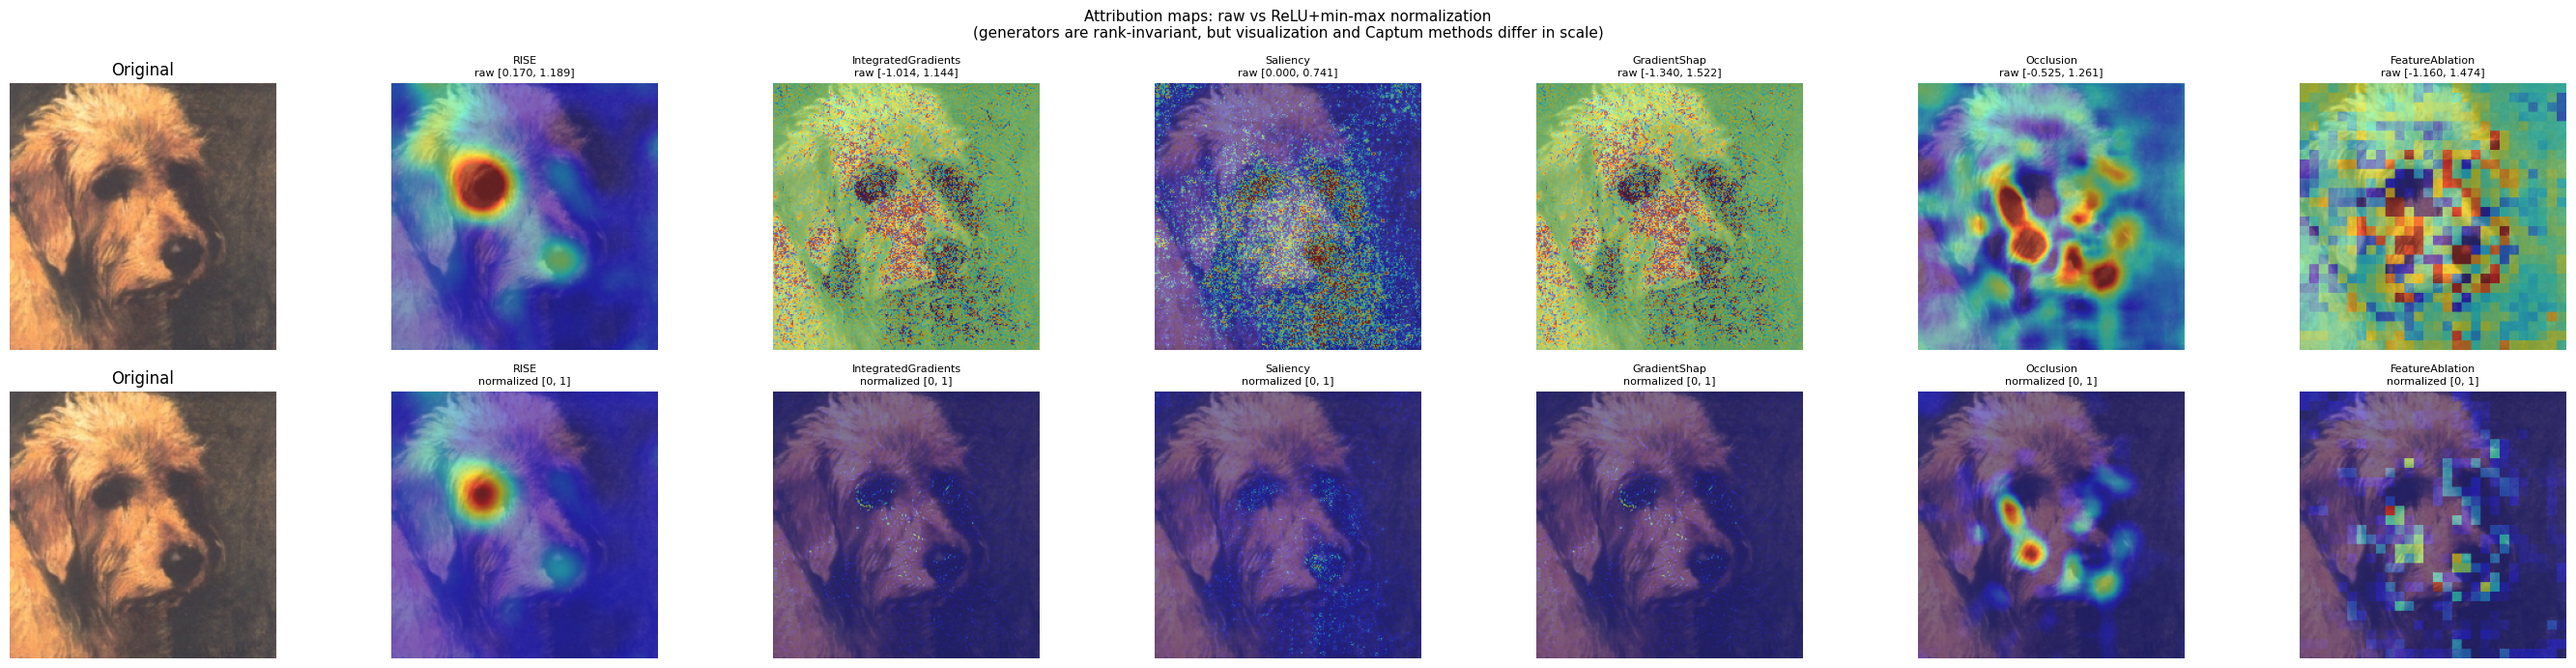

In [ ]:
img_display = denormalize(single_tensor.detach())
n_methods = len(methods)

fig, axes = plt.subplots(2, n_methods + 1, figsize=(4 * (n_methods + 1), 7))

for row in range(2):
    axes[row, 0].imshow(img_display)
    axes[row, 0].axis("off")
    axes[row, 0].set_title("Original")

for col, method in enumerate(methods, start=1):
    sal_raw = saliency_maps[method]
    sal_norm = normalize_saliency(sal_raw)

    # Top row: raw (clipped for display, but shows real scale in title)
    sal_disp = np.clip(sal_raw, np.percentile(sal_raw, 2), np.percentile(sal_raw, 98))
    sal_disp = (sal_disp - sal_disp.min()) / (sal_disp.max() - sal_disp.min() + 1e-8)
    axes[0, col].imshow(img_display)
    axes[0, col].imshow(sal_disp, cmap="jet", alpha=0.5)
    axes[0, col].axis("off")
    axes[0, col].set_title(
        f"{method_labels[method]}\nraw [{sal_raw.min():.3f}, {sal_raw.max():.3f}]",
        fontsize=8,
    )

    # Bottom row: normalized [0, 1]
    axes[1, col].imshow(img_display)
    axes[1, col].imshow(sal_norm, cmap="jet", alpha=0.5)
    axes[1, col].axis("off")
    axes[1, col].set_title(f"{method_labels[method]}\nnormalized [0, 1]", fontsize=8)

axes[0, 0].set_ylabel("Raw (clipped display)", fontsize=9)
axes[1, 0].set_ylabel("Normalized [0, 1]", fontsize=9)
plt.suptitle(
    "Attribution maps: raw vs ReLU+min-max normalization\n"
    "(generators are rank-invariant, but visualization and Captum methods differ in scale)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## Section 5 — Attribution Method Comparison

All six methods on ResNet50 + BucketDeletion(25), N=20 images.
Metrics: deletion AUC (map quality), ECE and TACE before/after calibration.

In [ ]:
METHODS_ALL = ["rise", "ig", "lime", "gradientshap", "saliency", "feature_ablation"]
METHOD_LABELS = {
    "rise": "RISE",
    "ig": "IntGrad",
    "lime": "LIME",
    "gradientshap": "GradShap",
    "saliency": "Saliency",
    "feature_ablation": "FeatAblation",
}

# Reuse RISE maps already computed; compute the rest fresh
method_sals_all = {"rise": rise_sals}

for method in tqdm(METHODS_ALL[1:], desc="Saliency maps"):
    sals = []
    for i, (_, tensor) in enumerate(samples):
        sal = (
            pipeline.generate_map(tensor.to(device), target_classes[i], method)
            .cpu()
            .numpy()
        )
        sals.append(sal)
    method_sals_all[method] = sals
    print(f"  {method}: done")

print("All saliency maps ready.")

Saliency maps:  20%|██        | 1/5 [00:07<00:28,  7.10s/it]

  ig: done


/usr/local/lib/python3.12/dist-packages/captum/attr/_core/lime.py:1154: UserWarning: Attempting to construct interpretable model with > 10000 features.This can be very slow or lead to OOM issues. Please provide a featuremask which groups input features to reduce the number of interpretablefeatures. 
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/captum/attr/_core/lime.py:1154: UserWarning: Attempting to construct interpretable model with > 10000 features.This can be very slow or lead to OOM issues. Please provide a featuremask which groups input features to reduce the number of interpretablefeatures. 
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/captum/attr/_core/lime.py:1154: UserWarning: Attempting to construct interpretable model with > 10000 features.This can be very slow or lead to OOM issues. Please provide a featuremask which groups input features to reduce the number of interpretablefeatures. 
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/captum

  lime: done


Saliency maps:  60%|██████    | 3/5 [03:32<02:16, 68.38s/it] 

  gradientshap: done


Saliency maps:  80%|████████  | 4/5 [03:33<00:41, 41.49s/it]

  saliency: done


Saliency maps: 100%|██████████| 5/5 [05:15<00:00, 63.08s/it]

  feature_ablation: done
All saliency maps ready.


In [ ]:
gen_bkt25 = BucketDeletionGenerator(num_buckets=25)
method_results = {}

for method in tqdm(METHODS_ALL, desc="Methods"):
    sals_m = method_sals_all[method]

    # Pass 1: raw logits for calibration + cache raw probs
    m_logits_bins = {b: [] for b in range(NUM_BINS)}
    m_labels_bins = {b: [] for b in range(NUM_BINS)}
    raw_cache = []

    for i in range(len(samples)):
        tensor = img_batch[i : i + 1]
        tc = target_classes[i]
        sal_t = torch.from_numpy(normalize_saliency(sals_m[i]))
        seq, lvl = gen_bkt25(tensor.cpu(), sal_t)

        with torch.no_grad():
            step_logits = raw_model(seq.to(device)).cpu().numpy()

        for step_idx, logits in enumerate(step_logits):
            b = min(int(lvl[step_idx] * NUM_BINS), NUM_BINS - 1)
            m_logits_bins[b].append(logits)
            m_labels_bins[b].append(tc)

        _, raw_auc, raw_ap = evaluate_causal_metric(raw_model, seq.to(device), lvl, tc)
        raw_cache.append((raw_auc, raw_ap, tc, lvl))

    # Fit temperatures
    m_temps = [
        round(
            temperature_scaling(
                np.stack(m_logits_bins[b]), np.array(m_labels_bins[b], dtype=np.int64)
            ),
            4,
        )
        if len(m_logits_bins[b]) > 1
        else 1.0
        for b in range(NUM_BINS)
    ]
    m_recalx = ReCalXModel(raw_model, num_bins=NUM_BINS).to(device)
    m_recalx.load_learned_temperatures(m_temps)

    # Pass 2: calibrated evaluation
    auc_l, ece_r, ece_c, tace_r, tace_c = [], [], [], [], []
    for i, (raw_auc, raw_ap, tc, lvl) in enumerate(raw_cache):
        tensor = img_batch[i : i + 1]
        sal_t = torch.from_numpy(normalize_saliency(sals_m[i]))
        seq, lvl2 = gen_bkt25(tensor.cpu(), sal_t)
        labels_i = np.full(len(lvl), tc, dtype=np.int64)
        _, _, cal_ap = evaluate_causal_metric(m_recalx, seq.to(device), lvl2, tc)
        auc_l.append(raw_auc)
        ece_r.append(calculate_ece(raw_ap, labels_i))
        ece_c.append(calculate_ece(cal_ap, labels_i))
        tace_r.append(calculate_tace(raw_ap, labels_i))
        tace_c.append(calculate_tace(cal_ap, labels_i))

    method_results[method] = dict(
        auc=auc_l, ece_raw=ece_r, ece_cal=ece_c, tace_raw=tace_r, tace_cal=tace_c
    )
    print(
        f"  {METHOD_LABELS[method]:<14} "
        f"AUC {np.mean(auc_l):.3f}±{np.std(auc_l):.3f}  "
        f"ECE {np.mean(ece_r):.3f}→{np.mean(ece_c):.3f}"
    )

Methods:  17%|█▋        | 1/6 [00:05<00:28,  5.71s/it]

  RISE           AUC 0.175±0.121  ECE 0.272→0.167


Methods:  33%|███▎      | 2/6 [00:11<00:22,  5.70s/it]

  IntGrad        AUC 0.068±0.065  ECE 0.163→0.166


Methods:  50%|█████     | 3/6 [00:16<00:16,  5.63s/it]

...

  GradShap       AUC 0.083±0.091  ECE 0.169→0.161


Methods:  83%|████████▎ | 5/6 [00:28<00:05,  5.66s/it]

  Saliency       AUC 0.111±0.075  ECE 0.211→0.168


Methods: 100%|██████████| 6/6 [00:33<00:00,  5.66s/it]

  FeatAblation   AUC 0.205±0.135  ECE 0.390→0.205


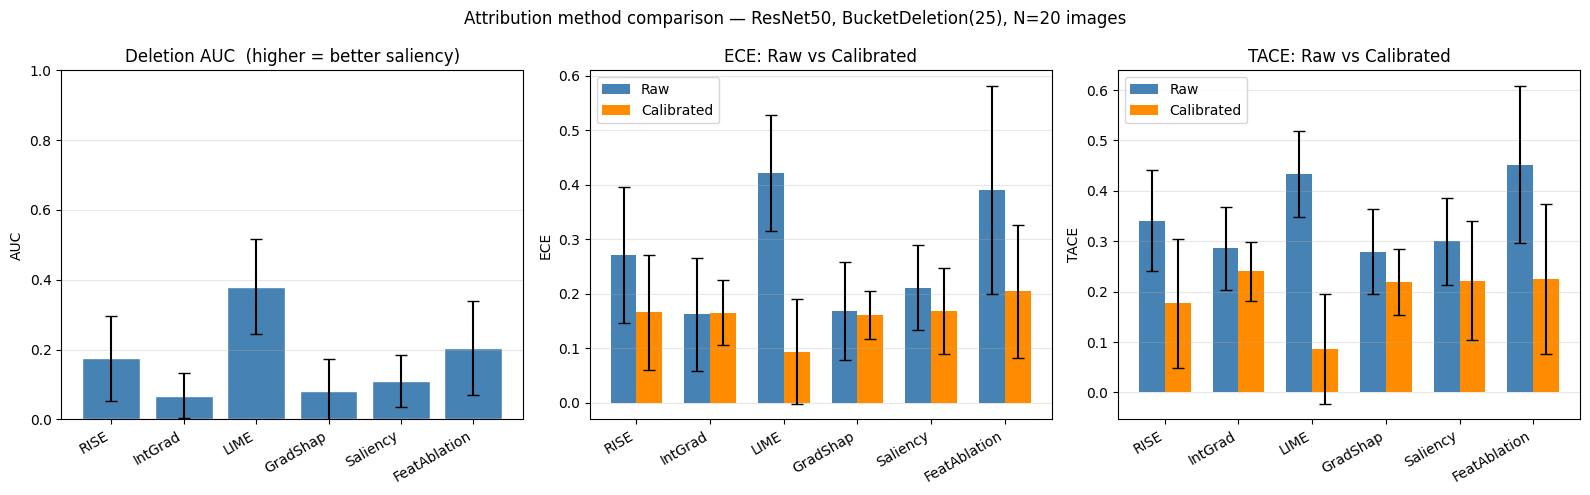

Method                 AUC   ECE_raw   ECE_cal     ΔECE
-------------------------------------------------------
RISE                 0.175     0.272     0.167   -0.105
IntGrad              0.068     0.163     0.166   +0.003
LIME                 0.380     0.422     0.094   -0.328
GradShap             0.083     0.169     0.161   -0.008
Saliency             0.111     0.211     0.168   -0.043
FeatAblation         0.205     0.390     0.205   -0.186


In [ ]:
x = np.arange(len(METHODS_ALL))
w = 0.35
labels_x = [METHOD_LABELS[m] for m in METHODS_ALL]


def _m(key):
    return [np.mean(method_results[m][key]) for m in METHODS_ALL]


def _s(key):
    return [np.std(method_results[m][key]) for m in METHODS_ALL]


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(
    x, _m("auc"), yerr=_s("auc"), color="steelblue", capsize=4, edgecolor="white"
)
axes[0].set_title("Deletion AUC  (higher = better saliency)")
axes[0].set_ylabel("AUC")
axes[0].set_ylim(0, 1)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_x, rotation=30, ha="right")
axes[0].grid(axis="y", alpha=0.3)

for ax, metric in zip(axes[1:], ["ece", "tace"]):
    ax.bar(
        x - w / 2,
        _m(f"{metric}_raw"),
        w,
        yerr=_s(f"{metric}_raw"),
        label="Raw",
        color="steelblue",
        capsize=4,
    )
    ax.bar(
        x + w / 2,
        _m(f"{metric}_cal"),
        w,
        yerr=_s(f"{metric}_cal"),
        label="Calibrated",
        color="darkorange",
        capsize=4,
    )
    ax.set_title(f"{metric.upper()}: Raw vs Calibrated")
    ax.set_ylabel(metric.upper())
    ax.legend()
    ax.set_xticks(x)
    ax.set_xticklabels(labels_x, rotation=30, ha="right")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Attribution method comparison — ResNet50, BucketDeletion(25), N=20 images",
    fontsize=12,
)
plt.tight_layout()
plt.show()

# Summary table
print(f"{'Method':<18} {'AUC':>7} {'ECE_raw':>9} {'ECE_cal':>9} {'ΔECE':>8}")
print("-" * 55)
for m in METHODS_ALL:
    r = method_results[m]
    delta = np.mean(r["ece_cal"]) - np.mean(r["ece_raw"])
    print(
        f"{METHOD_LABELS[m]:<18} {np.mean(r['auc']):>7.3f}"
        f" {np.mean(r['ece_raw']):>9.3f} {np.mean(r['ece_cal']):>9.3f} {delta:>+8.3f}"
    )

## Section 6 — TopN(1%) vs Bucket(25) Deletion

TopN removes pixels in 1% increments (100 steps, fine-grained).
Bucket removes pixels in 25 equal-count groups (coarser, but aligned with calibration bins).
Using RISE saliency + ResNet50.

TopN(1%)   102 steps  AUC=0.0495
Bucket(25)  26 steps  AUC=0.0456


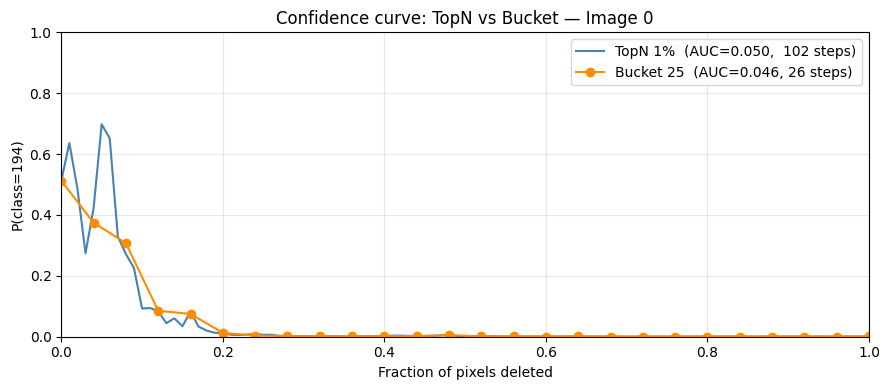

In [ ]:
# Single image: compare confidence curves
gen_topn = TopNDeletionGenerator(step_fraction=0.01)  # 100 steps
gen_bkt25b = BucketDeletionGenerator(num_buckets=25)  # 25 steps

sal_t = torch.from_numpy(normalize_saliency(rise_sals[IMG_IDX]))

seq_topn, lvl_topn = gen_topn(single_tensor.cpu(), sal_t)
seq_bucket, lvl_bucket = gen_bkt25b(single_tensor.cpu(), sal_t)

probs_topn, auc_topn, _ = evaluate_causal_metric(
    raw_model, seq_topn.to(device), lvl_topn, target_class
)
probs_bucket, auc_bucket, _ = evaluate_causal_metric(
    raw_model, seq_bucket.to(device), lvl_bucket, target_class
)

print(f"TopN(1%)   {len(lvl_topn):3d} steps  AUC={auc_topn:.4f}")
print(f"Bucket(25) {len(lvl_bucket):3d} steps  AUC={auc_bucket:.4f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    lvl_topn,
    probs_topn,
    color="steelblue",
    label=f"TopN 1%  (AUC={auc_topn:.3f},  {len(lvl_topn)} steps)",
)
ax.plot(
    lvl_bucket,
    probs_bucket,
    "o-",
    color="darkorange",
    label=f"Bucket 25  (AUC={auc_bucket:.3f}, {len(lvl_bucket)} steps)",
)
ax.set_xlabel("Fraction of pixels deleted")
ax.set_ylabel(f"P(class={target_class})")
ax.set_title(f"Confidence curve: TopN vs Bucket — Image {IMG_IDX}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Batch: calibrate both generators, compare ECE/TACE
gen_configs = {
    "TopN(1%)": TopNDeletionGenerator(step_fraction=0.01),
    "Bucket(25)": BucketDeletionGenerator(num_buckets=25),
}
gen_results = {}

for gen_name, gen in gen_configs.items():
    g_logits_bins = {b: [] for b in range(NUM_BINS)}
    g_labels_bins = {b: [] for b in range(NUM_BINS)}

    for i in range(len(samples)):
        tensor = img_batch[i : i + 1]
        tc = target_classes[i]
        sal_t = torch.from_numpy(normalize_saliency(rise_sals[i]))
        seq, lvl = gen(tensor.cpu(), sal_t)
        with torch.no_grad():
            step_logits = raw_model(seq.to(device)).cpu().numpy()
        for step_idx, logits in enumerate(step_logits):
            b = min(int(lvl[step_idx] * NUM_BINS), NUM_BINS - 1)
            g_logits_bins[b].append(logits)
            g_labels_bins[b].append(tc)

    g_temps = [
        round(
            temperature_scaling(
                np.stack(g_logits_bins[b]), np.array(g_labels_bins[b], dtype=np.int64)
            ),
            4,
        )
        if len(g_logits_bins[b]) > 1
        else 1.0
        for b in range(NUM_BINS)
    ]
    print(f"{gen_name} samples/bin: {[len(g_logits_bins[b]) for b in range(NUM_BINS)]}")

    g_recalx = ReCalXModel(raw_model, num_bins=NUM_BINS).to(device)
    g_recalx.load_learned_temperatures(g_temps)

    ece_r, ece_c, tace_r, tace_c = [], [], [], []
    for i in range(len(samples)):
        tensor = img_batch[i : i + 1]
        tc = target_classes[i]
        sal_t = torch.from_numpy(normalize_saliency(rise_sals[i]))
        seq, lvl = gen(tensor.cpu(), sal_t)
        labels_i = np.full(len(lvl), tc, dtype=np.int64)
        _, _, raw_ap = evaluate_causal_metric(raw_model, seq.to(device), lvl, tc)
        _, _, cal_ap = evaluate_causal_metric(g_recalx, seq.to(device), lvl, tc)
        ece_r.append(calculate_ece(raw_ap, labels_i))
        ece_c.append(calculate_ece(cal_ap, labels_i))
        tace_r.append(calculate_tace(raw_ap, labels_i))
        tace_c.append(calculate_tace(cal_ap, labels_i))

    gen_results[gen_name] = dict(
        ece_raw=ece_r, ece_cal=ece_c, tace_raw=tace_r, tace_cal=tace_c
    )
    print(
        f"  ECE  {np.mean(ece_r):.3f}±{np.std(ece_r):.3f} → {np.mean(ece_c):.3f}±{np.std(ece_c):.3f}"
    )
    print(
        f"  TACE {np.mean(tace_r):.3f}±{np.std(tace_r):.3f} → {np.mean(tace_c):.3f}±{np.std(tace_c):.3f}"
    )

TopN(1%) samples/bin: [200, 200, 200, 200, 200, 200, 200, 200, 200, 240]
  ECE  0.259±0.131 → 0.153±0.104
  TACE 0.283±0.124 → 0.157±0.108
Bucket(25) samples/bin: [60, 60, 40, 60, 40, 60, 40, 60, 40, 60]
  ECE  0.272±0.125 → 0.167±0.105
  TACE 0.341±0.100 → 0.177±0.128


/tmp/ipykernel_604/3280705018.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=tick_lbls, patch_artist=True,
/tmp/ipykernel_604/3280705018.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=tick_lbls, patch_artist=True,


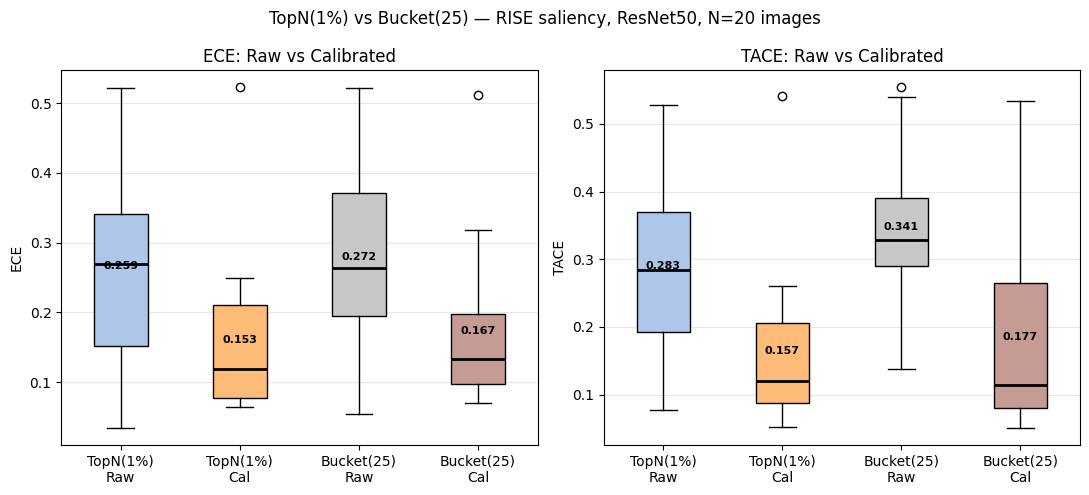

In [ ]:
gen_names = list(gen_results.keys())

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, metric in zip(axes, ["ece", "tace"]):
    data = []
    tick_lbls = []
    for g in gen_names:
        data += [gen_results[g][f"{metric}_raw"], gen_results[g][f"{metric}_cal"]]
        tick_lbls += [f"{g}\nRaw", f"{g}\nCal"]

    bp = ax.boxplot(
        data,
        labels=tick_lbls,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
    )
    face_colors = ["#aec7e8", "#ffbb78", "#c7c7c7", "#c49c94"]
    for patch, fc in zip(bp["boxes"], face_colors):
        patch.set_facecolor(fc)

    for pos, vals in enumerate(data, 1):
        ax.text(
            pos,
            np.mean(vals),
            f"{np.mean(vals):.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
        )

    ax.set_title(f"{metric.upper()}: Raw vs Calibrated")
    ax.set_ylabel(metric.upper())
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "TopN(1%) vs Bucket(25) — RISE saliency, ResNet50, N=20 images", fontsize=12
)
plt.tight_layout()
plt.show()

## Section 7 — ViT-B/16 vs ResNet50

Load ViT-B/16 with its own RISE explainer (N=2000 masks for speed; use N=5000 for better saliency quality).
Same evaluation as Section 3: BucketDeletion(25), N=20 images.

In [ ]:
from torchvision.models import ViT_B_16_Weights, vit_b_16

from src.RISE import RISE as SrcRISE

print("Loading ViT-B/16...")
vit_raw = vit_b_16(weights=ViT_B_16_Weights.DEFAULT).to(device).eval()
for p in vit_raw.parameters():
    p.requires_grad = False

# RISE for ViT — N=2000 is faster; raise to 5000 for publication-quality maps
print("Generating RISE masks for ViT...")
vit_rise = SrcRISE(vit_raw, (224, 224))
vit_rise.generate_masks(N=2000, s=10, p1=0.1)

with torch.no_grad():
    vit_target_classes = [
        int(torch.argmax(torch.softmax(vit_raw(t.to(device)), dim=1)).item())
        for _, t in samples
    ]

n_agree = sum(a == b for a, b in zip(target_classes, vit_target_classes))
print(f"ResNet50 and ViT agree on {n_agree}/20 images top-1 class.")

Loading ViT-B/16...
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:06<00:00, 53.6MB/s]


Generating RISE masks for ViT...


Generating filters: 100%|██████████| 2000/2000 [00:05<00:00, 351.02it/s]


ResNet50 and ViT agree on 19/20 images top-1 class.


In [33]:
vit_rise_sals = []
for i, (_, tensor) in enumerate(tqdm(samples, desc="ViT RISE saliency")):
    with torch.no_grad():
        sal = vit_rise(tensor.cuda())[vit_target_classes[i]].cpu().numpy()
    vit_rise_sals.append(sal)

print("ViT RISE saliency shape:", np.array(vit_rise_sals).shape)

ViT RISE saliency: 100%|██████████| 20/20 [08:38<00:00, 25.90s/it]

ViT RISE saliency shape: (20, 224, 224)


In [ ]:
gen_bkt25v = BucketDeletionGenerator(num_buckets=25)

vit_logits_bins = {b: [] for b in range(NUM_BINS)}
vit_labels_bins = {b: [] for b in range(NUM_BINS)}

for i in tqdm(range(len(samples)), desc="ViT logit collection"):
    tensor = img_batch[i : i + 1]
    tc = vit_target_classes[i]
    sal_t = torch.from_numpy(normalize_saliency(vit_rise_sals[i]))
    seq, lvl = gen_bkt25v(tensor.cpu(), sal_t)
    with torch.no_grad():
        step_logits = vit_raw(seq.to(device)).cpu().numpy()
    for step_idx, logits in enumerate(step_logits):
        b = min(int(lvl[step_idx] * NUM_BINS), NUM_BINS - 1)
        vit_logits_bins[b].append(logits)
        vit_labels_bins[b].append(tc)

vit_temps = [
    round(
        temperature_scaling(
            np.stack(vit_logits_bins[b]), np.array(vit_labels_bins[b], dtype=np.int64)
        ),
        4,
    )
    if len(vit_logits_bins[b]) > 1
    else 1.0
    for b in range(NUM_BINS)
]
vit_recalx = ReCalXModel(vit_raw, num_bins=NUM_BINS).to(device)
vit_recalx.load_learned_temperatures(vit_temps)

vit_ece_raws, vit_ece_cals = [], []
vit_tace_raws, vit_tace_cals = [], []

for i in tqdm(range(len(samples)), desc="ViT eval"):
    tensor = img_batch[i : i + 1]
    tc = vit_target_classes[i]
    sal_t = torch.from_numpy(normalize_saliency(vit_rise_sals[i]))
    seq, lvl = gen_bkt25v(tensor.cpu(), sal_t)
    labels_i = np.full(len(lvl), tc, dtype=np.int64)
    _, _, vit_raw_ap = evaluate_causal_metric(vit_raw, seq.to(device), lvl, tc)
    _, _, vit_cal_ap = evaluate_causal_metric(vit_recalx, seq.to(device), lvl, tc)
    vit_ece_raws.append(calculate_ece(vit_raw_ap, labels_i))
    vit_ece_cals.append(calculate_ece(vit_cal_ap, labels_i))
    vit_tace_raws.append(calculate_tace(vit_raw_ap, labels_i))
    vit_tace_cals.append(calculate_tace(vit_cal_ap, labels_i))

print(
    f"ViT  ECE  raw={np.mean(vit_ece_raws):.4f}±{np.std(vit_ece_raws):.4f}  cal={np.mean(vit_ece_cals):.4f}±{np.std(vit_ece_cals):.4f}"
)
print(
    f"ViT  TACE raw={np.mean(vit_tace_raws):.4f}±{np.std(vit_tace_raws):.4f}  cal={np.mean(vit_tace_cals):.4f}±{np.std(vit_tace_cals):.4f}"
)

ViT eval: 100%|██████████| 20/20 [00:14<00:00,  1.34it/s]

ViT  ECE  raw=0.2091±0.0571  cal=0.1490±0.0553
ViT  TACE raw=0.2385±0.0658  cal=0.1907±0.0977


/tmp/ipykernel_604/332734338.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=tick_lbls, patch_artist=True,
/tmp/ipykernel_604/332734338.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=tick_lbls, patch_artist=True,


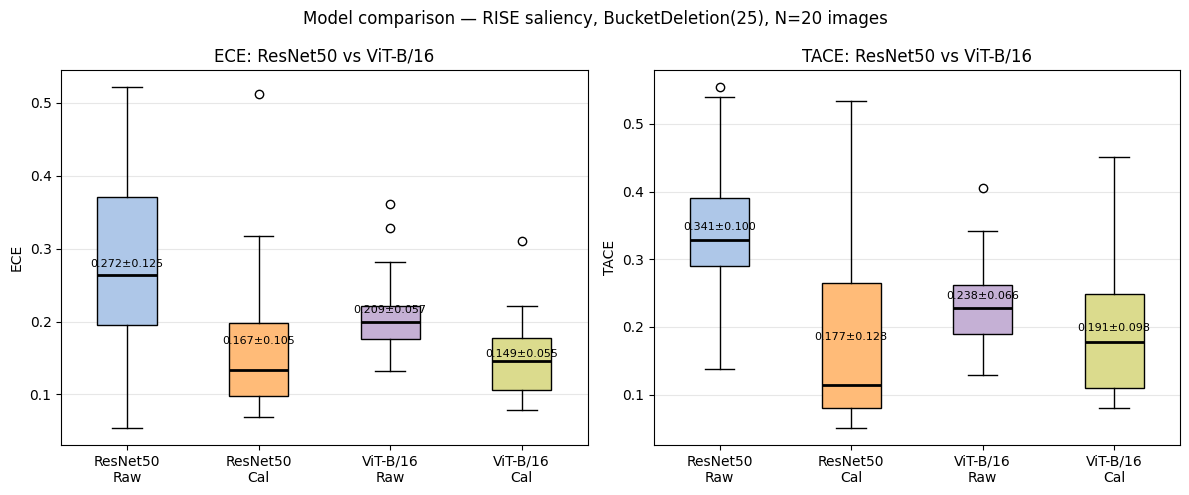

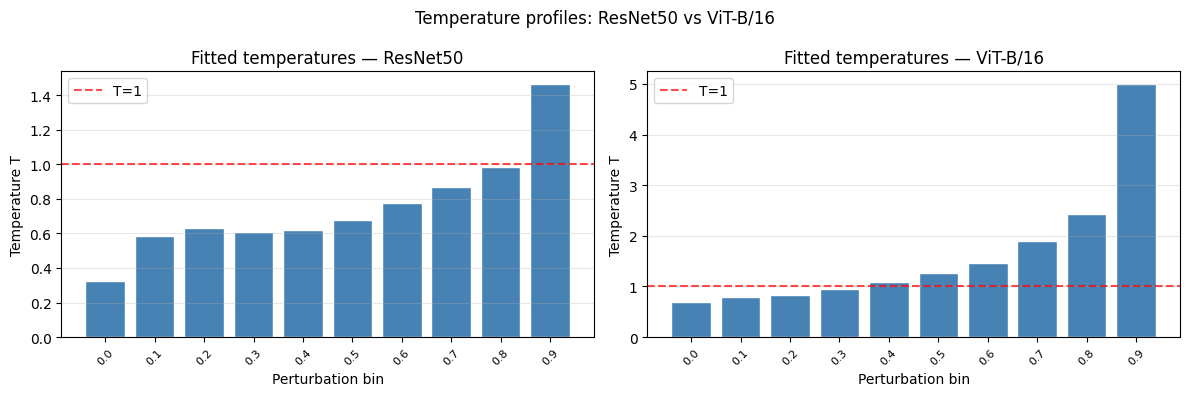

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

data_groups = {
    "ECE": [ece_raws, ece_cals, vit_ece_raws, vit_ece_cals],
    "TACE": [tace_raws, tace_cals, vit_tace_raws, vit_tace_cals],
}
tick_lbls = ["ResNet50\nRaw", "ResNet50\nCal", "ViT-B/16\nRaw", "ViT-B/16\nCal"]
face_colors = ["#aec7e8", "#ffbb78", "#c5b0d5", "#dbdb8d"]

for ax, (metric, data) in zip(axes, data_groups.items()):
    bp = ax.boxplot(
        data,
        labels=tick_lbls,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
    )
    for patch, fc in zip(bp["boxes"], face_colors):
        patch.set_facecolor(fc)
    for pos, vals in enumerate(data, 1):
        ax.text(
            pos,
            np.mean(vals),
            f"{np.mean(vals):.3f}±{np.std(vals):.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )
    ax.set_title(f"{metric}: ResNet50 vs ViT-B/16")
    ax.set_ylabel(metric)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Model comparison — RISE saliency, BucketDeletion(25), N=20 images", fontsize=12
)
plt.tight_layout()
plt.show()

# Temperature profile comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins_x = np.arange(NUM_BINS)
for ax, (model_name, temps) in zip(
    axes, [("ResNet50", batch_temps), ("ViT-B/16", vit_temps)]
):
    ax.bar(bins_x, temps, color="steelblue", edgecolor="white")
    ax.axhline(1.0, color="red", linestyle="--", alpha=0.7, label="T=1")
    ax.set_xlabel("Perturbation bin")
    ax.set_ylabel("Temperature T")
    ax.set_title(f"Fitted temperatures — {model_name}")
    ax.set_xticks(bins_x)
    ax.set_xticklabels(
        [f"{b / NUM_BINS:.1f}" for b in range(NUM_BINS)], rotation=45, fontsize=8
    )
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("Temperature profiles: ResNet50 vs ViT-B/16", fontsize=12)
plt.tight_layout()
plt.show()

## Section 8 — Spearman Correlation & Monotonicity per Attribution Method

Spearman rank correlation between perturbation level and model confidence:
- **Deletion ideal**: r = −1 (confidence falls monotonically as more pixels removed)
- **Insertion ideal**: r = +1

`calculate_spearman` truncates the flat tail of each curve before computing r
(per the professor's instruction: "measure only until the curve becomes flat").
`calculate_monotonicity_ratio` gives the fraction of consecutive steps that move
in the expected direction — a direct 0–1 monotonicity score.

In [ ]:
from src.metrics import (
    calculate_spearman,
    calculate_monotonicity_ratio,
    test_calibration_significance,
)

# Rebuild batch-calibrated ResNet50 (batch_temps fitted on RISE in Section 3)
recalx_batch = ReCalXModel(raw_model, num_bins=NUM_BINS).to(device)
recalx_batch.load_learned_temperatures(batch_temps)
recalx_batch.eval()

# Reuse method_sals_all from Section 5 — no re-attribution needed, just forward passes
curve_data = {}  # method -> list of dicts with raw/cal probs and AUC

for method in tqdm(METHODS_ALL, desc="Collecting prob curves"):
    sals_m = method_sals_all[method]
    entries = []
    for i in range(len(samples)):
        tensor = img_batch[i : i + 1]
        tc = target_classes[i]
        sal_t = torch.from_numpy(normalize_saliency(sals_m[i]))
        seq, lvl = gen_bkt25(tensor.cpu(), sal_t)
        raw_probs, raw_auc, _ = evaluate_causal_metric(raw_model, seq.to(device), lvl, tc)
        cal_probs, cal_auc, _ = evaluate_causal_metric(recalx_batch, seq.to(device), lvl, tc)
        entries.append({
            "raw_probs": raw_probs, "cal_probs": cal_probs,
            "levels": lvl, "raw_auc": raw_auc, "cal_auc": cal_auc,
        })
    curve_data[method] = entries

print("curve_data ready — reused in Sections 9 and 11.")

In [ ]:
import pandas as pd

rows = []
for method in METHODS_ALL:
    entries = curve_data[method]
    rsp = [calculate_spearman(e["raw_probs"], e["levels"]) for e in entries]
    rmo = [calculate_monotonicity_ratio(e["raw_probs"], mode="deletion") for e in entries]
    csp = [calculate_spearman(e["cal_probs"], e["levels"]) for e in entries]
    cmo = [calculate_monotonicity_ratio(e["cal_probs"], mode="deletion") for e in entries]
    rows.append({
        "Method": METHOD_LABELS[method],
        "Spearman r  raw": f"{np.mean(rsp):+.3f} ± {np.std(rsp):.3f}",
        "Monotonicity raw": f"{np.mean(rmo):.3f} ± {np.std(rmo):.3f}",
        "Spearman r  cal": f"{np.mean(csp):+.3f} ± {np.std(csp):.3f}",
        "Monotonicity cal": f"{np.mean(cmo):.3f} ± {np.std(cmo):.3f}",
    })

df_s8 = pd.DataFrame(rows).sort_values("Spearman r  raw")
print("Sorted by raw Spearman r (most negative = most monotone = best for deletion)\n")
print(df_s8.to_string(index=False))

In [ ]:
# Sort methods by raw Spearman ascending (most negative = best)
sort_idx = np.argsort(
    [np.mean([calculate_spearman(e["raw_probs"], e["levels"]) for e in curve_data[m]])
     for m in METHODS_ALL]
)
sorted_methods = [METHODS_ALL[i] for i in sort_idx]
sorted_labels  = [METHOD_LABELS[m] for m in sorted_methods]

raw_sp = [np.mean([calculate_spearman(e["raw_probs"], e["levels"]) for e in curve_data[m]]) for m in sorted_methods]
cal_sp = [np.mean([calculate_spearman(e["cal_probs"], e["levels"]) for e in curve_data[m]]) for m in sorted_methods]
raw_mo = [np.mean([calculate_monotonicity_ratio(e["raw_probs"]) for e in curve_data[m]]) for m in sorted_methods]
cal_mo = [np.mean([calculate_monotonicity_ratio(e["cal_probs"]) for e in curve_data[m]]) for m in sorted_methods]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(sorted_methods))
w = 0.35

for ax, raw_v, cal_v, title, ylabel, ideal_y, ideal_label in [
    (axes[0], raw_sp, cal_sp, "Spearman r (deletion, flat tail truncated)",
     "Spearman r", -1.0, "Ideal r=−1"),
    (axes[1], raw_mo, cal_mo, "Monotonicity Ratio (deletion)",
     "Fraction of monotone steps", 1.0, "Ideal = 1.0"),
]:
    ax.bar(x - w/2, raw_v, w, label="Raw",        color="steelblue", alpha=0.85)
    ax.bar(x + w/2, cal_v, w, label="Calibrated", color="coral",     alpha=0.85)
    ax.axhline(ideal_y, color="green", linestyle="--", linewidth=0.9, label=ideal_label)
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_labels, rotation=25, ha="right")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Monotonicity of deletion curves per attribution method\n"
    "ResNet50 · BucketDeletion(25) · N=20 images  |  Calibration = RISE batch temps (Section 3)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## Section 9 — Does Calibration Significantly Change AUC & Monotonicity?

Wilcoxon signed-rank test (non-parametric, paired) on N=20 images per method.
- H₀: calibration does not change the metric
- α = 0.05; * marks significant results

Metrics tested: deletion AUC and Spearman r (both use the batch-fitted RISE temperatures).

In [ ]:
print(f"{'Method':<16} {'ΔAUC med':>9} {'p(AUC)':>9}{'':>2} "
      f"{'ΔSpear med':>11} {'p(Spear)':>10}{'':>2} {'Sig?':>5}")
print("-" * 72)

sig_results = {}
for method in METHODS_ALL:
    entries = curve_data[method]
    raw_aucs = [e["raw_auc"] for e in entries]
    cal_aucs = [e["cal_auc"] for e in entries]
    raw_sp   = [calculate_spearman(e["raw_probs"], e["levels"]) for e in entries]
    cal_sp   = [calculate_spearman(e["cal_probs"], e["levels"]) for e in entries]

    _, p_auc = test_calibration_significance(raw_aucs, cal_aucs)
    _, p_sp  = test_calibration_significance(raw_sp,   cal_sp)

    d_auc = float(np.median(np.array(cal_aucs) - np.array(raw_aucs)))
    d_sp  = float(np.median(np.array(cal_sp)   - np.array(raw_sp)))
    sig   = "YES *" if p_auc < 0.05 or p_sp < 0.05 else "no"

    sig_results[method] = dict(
        d_auc=d_auc, p_auc=p_auc, d_sp=d_sp, p_sp=p_sp
    )

    auc_star = "*" if p_auc < 0.05 else " "
    sp_star  = "*" if p_sp  < 0.05 else " "
    print(f"{METHOD_LABELS[method]:<16} {d_auc:>+9.4f} {p_auc:>9.4f}{auc_star:>2} "
          f"{d_sp:>+11.4f} {p_sp:>10.4f}{sp_star:>2} {sig:>5}")

print("\nInterpretation (α=0.05, * = significant):")
for method in METHODS_ALL:
    r = sig_results[method]
    lbl = METHOD_LABELS[method]
    auc_str = f"AUC {'↓' if r['d_auc']<0 else '↑'} p={r['p_auc']:.3f}{'*' if r['p_auc']<0.05 else ''}"
    sp_str  = f"Spearman {'↓' if r['d_sp']<0 else '↑'} p={r['p_sp']:.3f}{'*' if r['p_sp']<0.05 else ''}"
    print(f"  {lbl}: {auc_str}  |  {sp_str}")

## Section 10 — Extended Architecture Comparison

Extends the ResNet50 vs ViT-B/16 comparison from Section 7 to a 2×2 grid:

| Family | Model |
|--------|-------|
| ResNet | ResNet50 (Section 3), **ResNet101** (new) |
| ViT    | ViT-B/16 (Section 7), **ViT-B/32** (new) |

All four use RISE saliency + BucketDeletion(25).  
New models use N=2000 RISE masks (vs 5000 for ResNet50) to keep runtime manageable.

In [ ]:
from torchvision.models import ResNet101_Weights, ViT_B_32_Weights, resnet101, vit_b_32
from src.RISE import RISE as SrcRISE

print("Loading ResNet101...")
rn101 = resnet101(weights=ResNet101_Weights.DEFAULT).to(device).eval()
for p in rn101.parameters():
    p.requires_grad = False

print("Loading ViT-B/32...")
vit32 = vit_b_32(weights=ViT_B_32_Weights.DEFAULT).to(device).eval()
for p in vit32.parameters():
    p.requires_grad = False

print("Generating RISE masks for ResNet101 (N=2000, ~2–3 min)...")
rise_rn101 = SrcRISE(rn101, (224, 224))
rise_rn101.generate_masks(N=2000, s=10, p1=0.1)

print("Generating RISE masks for ViT-B/32 (N=2000, ~2–3 min)...")
rise_vit32 = SrcRISE(vit32, (224, 224))
rise_vit32.generate_masks(N=2000, s=10, p1=0.1)
print("Done.")

In [ ]:
rn101_sals, vit32_sals = [], []
rn101_tcs,  vit32_tcs  = [], []

for _, tensor in tqdm(samples, desc="ResNet101 RISE saliency"):
    tensor = tensor.to(device)
    with torch.no_grad():
        tc = int(rn101(tensor).argmax().item())
    rise_rn101.eval()
    with torch.no_grad():
        sal = rise_rn101(tensor)[tc].cpu().numpy()
    rn101_sals.append(sal)
    rn101_tcs.append(tc)

for _, tensor in tqdm(samples, desc="ViT-B/32 RISE saliency"):
    tensor = tensor.to(device)
    with torch.no_grad():
        tc = int(vit32(tensor).argmax().item())
    rise_vit32.eval()
    with torch.no_grad():
        sal = rise_vit32(tensor)[tc].cpu().numpy()
    vit32_sals.append(sal)
    vit32_tcs.append(tc)

print("Saliency maps ready.")

In [ ]:
# Unified evaluation for all 4 architectures
# ResNet50 and ViT-B/16: reuse pre-computed saliency + retrain temperatures for fair comparison
arch_configs = [
    ("ResNet50",  raw_model, rise_sals,      target_classes),
    ("ResNet101", rn101,     rn101_sals,     rn101_tcs),
    ("ViT-B/16",  vit_raw,   vit_rise_sals,  vit_target_classes),
    ("ViT-B/32",  vit32,     vit32_sals,     vit32_tcs),
]

gen_bkt_arch = BucketDeletionGenerator(num_buckets=25)
arch_results = {}  # arch_name -> {raw_aucs, cal_aucs, raw_sp, cal_sp, temps}

for arch_name, model, saliency_maps, tcs in tqdm(arch_configs, desc="Architectures"):
    logits_b = {b: [] for b in range(NUM_BINS)}
    labels_b = {b: [] for b in range(NUM_BINS)}
    raw_aucs, raw_sp_list, sal_cache = [], [], []

    # Pass 1: logit collection + raw metrics
    for i in range(len(samples)):
        tensor = img_batch[i : i + 1]
        tc = tcs[i]
        sal_t = torch.from_numpy(normalize_saliency(saliency_maps[i]))
        seq, lvl = gen_bkt_arch(tensor.cpu(), sal_t)
        with torch.no_grad():
            step_logits = model(seq.to(device)).cpu().numpy()
        for step_idx, logits in enumerate(step_logits):
            b = min(int(lvl[step_idx] * NUM_BINS), NUM_BINS - 1)
            logits_b[b].append(logits)
            labels_b[b].append(tc)
        raw_probs, raw_auc, _ = evaluate_causal_metric(model, seq.to(device), lvl, tc)
        raw_aucs.append(raw_auc)
        raw_sp_list.append(calculate_spearman(raw_probs, lvl))
        sal_cache.append((sal_t, tc))

    # Fit per-bin temperatures
    arch_temps = []
    for b in range(NUM_BINS):
        lgt = logits_b[b]
        if len(lgt) > 1:
            t = temperature_scaling(
                np.stack(lgt), np.array(labels_b[b], dtype=np.int64)
            )
        else:
            t = 1.0
        arch_temps.append(round(t, 4))

    cal_model = ReCalXModel(model, num_bins=NUM_BINS).to(device)
    cal_model.load_learned_temperatures(arch_temps)
    cal_model.eval()

    # Pass 2: calibrated metrics (sequences regenerated from cached saliency — fast)
    cal_aucs, cal_sp_list = [], []
    for i in range(len(samples)):
        tensor = img_batch[i : i + 1]
        sal_t, tc = sal_cache[i]
        seq, lvl = gen_bkt_arch(tensor.cpu(), sal_t)
        cal_probs, cal_auc, _ = evaluate_causal_metric(cal_model, seq.to(device), lvl, tc)
        cal_aucs.append(cal_auc)
        cal_sp_list.append(calculate_spearman(cal_probs, lvl))

    arch_results[arch_name] = dict(
        raw_aucs=raw_aucs, cal_aucs=cal_aucs,
        raw_sp=raw_sp_list, cal_sp=cal_sp_list,
        temps=arch_temps,
    )
    print(
        f"  {arch_name:<12} raw AUC={np.mean(raw_aucs):.3f}  cal AUC={np.mean(cal_aucs):.3f}"
        f"  raw Spear={np.mean(raw_sp_list):+.3f}  cal Spear={np.mean(cal_sp_list):+.3f}"
    )

In [ ]:
# Summary table
print(f"{'Architecture':<12} {'AUC raw':>9} {'AUC cal':>9} {'ΔAUC':>7} "
      f"{'Spear raw':>10} {'Spear cal':>10} {'ΔSpear':>8}")
print("-" * 72)
for arch_name in [c[0] for c in arch_configs]:
    r = arch_results[arch_name]
    d_auc = np.mean(r["cal_aucs"]) - np.mean(r["raw_aucs"])
    d_sp  = np.mean(r["cal_sp"])   - np.mean(r["raw_sp"])
    print(f"{arch_name:<12} {np.mean(r['raw_aucs']):>9.3f} {np.mean(r['cal_aucs']):>9.3f} "
          f"{d_auc:>+7.3f} {np.mean(r['raw_sp']):>+10.3f} {np.mean(r['cal_sp']):>+10.3f} "
          f"{d_sp:>+8.3f}")

# Boxplot comparison
arch_names = [c[0] for c in arch_configs]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, raw_key, cal_key, ylabel, title in [
    (axes[0], "raw_aucs", "cal_aucs", "AUC",      "Deletion AUC"),
    (axes[1], "raw_sp",   "cal_sp",   "Spearman r","Spearman r (truncated flat)"),
]:
    data  = [arch_results[n][raw_key] for n in arch_names]
    data += [arch_results[n][cal_key] for n in arch_names]
    tick_lbls = [f"{n}\nRaw" for n in arch_names] + [f"{n}\nCal" for n in arch_names]
    colors = (["#aec7e8"] * 4) + (["#ffbb78"] * 4)

    bp = ax.boxplot(data, labels=tick_lbls, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2))
    for patch, fc in zip(bp["boxes"], colors):
        patch.set_facecolor(fc)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Architecture comparison: 2×ResNet + 2×ViT — RISE · BucketDeletion(25) · N=20",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Section 11 — Bucketing Impact on Monotonicity

Section 6 compared TopN(1%) vs Bucket(25) using ECE/TACE.  
Here we extend that comparison with Spearman r and monotonicity ratio, and test
whether the difference is statistically significant (Wilcoxon test).

In [ ]:
gen_configs_s11 = {
    "TopN(1%)":   TopNDeletionGenerator(step_fraction=0.01),
    "Bucket(25)": BucketDeletionGenerator(num_buckets=25),
}
gen_spearman = {}  # gen_name -> {raw_sp, cal_sp, raw_mono, cal_mono}

for gen_name, gen in gen_configs_s11.items():
    # Collect logits for calibration with this generator
    g_logits_b = {b: [] for b in range(NUM_BINS)}
    g_labels_b = {b: [] for b in range(NUM_BINS)}
    raw_sp_list, raw_mono_list, sal_cache_g = [], [], []

    for i in range(len(samples)):
        tensor = img_batch[i : i + 1]
        tc = target_classes[i]
        sal_t = torch.from_numpy(normalize_saliency(rise_sals[i]))
        seq, lvl = gen(tensor.cpu(), sal_t)
        with torch.no_grad():
            step_logits = raw_model(seq.to(device)).cpu().numpy()
        for step_idx, logits in enumerate(step_logits):
            b = min(int(lvl[step_idx] * NUM_BINS), NUM_BINS - 1)
            g_logits_b[b].append(logits)
            g_labels_b[b].append(tc)
        raw_probs, _, _ = evaluate_causal_metric(raw_model, seq.to(device), lvl, tc)
        raw_sp_list.append(calculate_spearman(raw_probs, lvl))
        raw_mono_list.append(calculate_monotonicity_ratio(raw_probs, mode="deletion"))
        sal_cache_g.append(sal_t)

    g_temps = [
        round(
            temperature_scaling(
                np.stack(g_logits_b[b]), np.array(g_labels_b[b], dtype=np.int64)
            ), 4,
        ) if len(g_logits_b[b]) > 1 else 1.0
        for b in range(NUM_BINS)
    ]
    g_recalx = ReCalXModel(raw_model, num_bins=NUM_BINS).to(device)
    g_recalx.load_learned_temperatures(g_temps)
    g_recalx.eval()

    cal_sp_list, cal_mono_list = [], []
    for i in range(len(samples)):
        tensor = img_batch[i : i + 1]
        tc = target_classes[i]
        seq, lvl = gen(tensor.cpu(), sal_cache_g[i])
        cal_probs, _, _ = evaluate_causal_metric(g_recalx, seq.to(device), lvl, tc)
        cal_sp_list.append(calculate_spearman(cal_probs, lvl))
        cal_mono_list.append(calculate_monotonicity_ratio(cal_probs, mode="deletion"))

    gen_spearman[gen_name] = dict(
        raw_sp=raw_sp_list, cal_sp=cal_sp_list,
        raw_mono=raw_mono_list, cal_mono=cal_mono_list,
    )
    print(f"{gen_name}: raw Spear={np.mean(raw_sp_list):+.3f}  cal Spear={np.mean(cal_sp_list):+.3f}"
          f"  raw mono={np.mean(raw_mono_list):.3f}  cal mono={np.mean(cal_mono_list):.3f}")

In [ ]:
# Statistical significance: does bucketing improve Spearman vs TopN?
_, p_sp   = test_calibration_significance(
    gen_spearman["TopN(1%)"]["raw_sp"], gen_spearman["Bucket(25)"]["raw_sp"]
)
_, p_mono = test_calibration_significance(
    gen_spearman["TopN(1%)"]["raw_mono"], gen_spearman["Bucket(25)"]["raw_mono"]
)
print(f"Bucket vs TopN  Spearman: p={p_sp:.4f}{'*' if p_sp<0.05 else ' (n.s.)'}")
print(f"Bucket vs TopN  Monotonicity: p={p_mono:.4f}{'*' if p_mono<0.05 else ' (n.s.)'}")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
gen_names = list(gen_spearman.keys())
x = np.arange(len(gen_names))
w = 0.35

for ax, raw_key, cal_key, title, ylabel in [
    (axes[0], "raw_sp",   "cal_sp",   "Spearman r (deletion)",   "Spearman r"),
    (axes[1], "raw_mono", "cal_mono", "Monotonicity Ratio (deletion)", "Fraction monotone"),
]:
    raw_v = [np.mean(gen_spearman[g][raw_key]) for g in gen_names]
    cal_v = [np.mean(gen_spearman[g][cal_key]) for g in gen_names]
    raw_e = [np.std(gen_spearman[g][raw_key])  for g in gen_names]
    cal_e = [np.std(gen_spearman[g][cal_key])  for g in gen_names]
    ax.bar(x - w/2, raw_v, w, yerr=raw_e, label="Raw",        color="steelblue", capsize=4)
    ax.bar(x + w/2, cal_v, w, yerr=cal_e, label="Calibrated", color="coral",     capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(gen_names)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "TopN(1%) vs Bucket(25) — Spearman r & Monotonicity\n"
    "ResNet50 · RISE saliency · N=20 images", fontsize=11,
)
plt.tight_layout()
plt.show()

In [ ]:
# ── Save results for presentation notebook ────────────────────────────────
import pickle, pathlib, sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # Repo is cloned to /content/causal_calibration in Colab cell 0
    SAVE_DIR = pathlib.Path('/content/causal_calibration/results')
else:
    SAVE_DIR = pathlib.Path(os.path.dirname(os.path.abspath('__file__'))).parent / 'results'
SAVE_DIR.mkdir(parents=True, exist_ok=True)
SAVE_PATH = SAVE_DIR / 'calibration_results.pkl'

def _try(name):
    return globals().get(name)

save_data = {
    # Section 3
    'ece_raws':       _try('ece_raws'),
    'ece_cals':       _try('ece_cals'),
    'tace_raws':      _try('tace_raws'),
    'tace_cals':      _try('tace_cals'),
    'batch_temps':    _try('batch_temps'),
    'NUM_BINS':       _try('NUM_BINS'),
    # Section 2 single-image
    'IMG_IDX':        _try('IMG_IDX'),
    'lvl_del':        _try('lvl_del'),
    'raw_probs':      _try('raw_probs'),
    'raw_all_probs':  _try('raw_all_probs'),
    'cal_probs':      _try('cal_probs'),
    'raw_auc':        _try('raw_auc'),
    'seq_del':        _try('seq_del'),
    'target_class':   _try('target_class'),
    'single_img_np':  (
        (img_batch[IMG_IDX].permute(1,2,0).cpu().numpy()
         * __import__('numpy').array([0.229,0.224,0.225])
         + __import__('numpy').array([0.485,0.456,0.406]))
        .clip(0, 1)
        if 'img_batch' in dir() and 'IMG_IDX' in dir() else None
    ),
    'rise_sal_np':    (rise_sals[IMG_IDX] if 'rise_sals' in dir() and 'IMG_IDX' in dir() else None),
    # Section 5
    'method_results': _try('method_results'),
    'METHODS_ALL':    _try('METHODS_ALL'),
    'METHOD_LABELS':  _try('METHOD_LABELS'),
    # Section 7
    'vit_ece_raws':   _try('vit_ece_raws'),
    'vit_ece_cals':   _try('vit_ece_cals'),
    'vit_tace_raws':  _try('vit_tace_raws'),
    'vit_tace_cals':  _try('vit_tace_cals'),
    'vit_temps':      _try('vit_temps'),
    # Sections 8-9
    'curve_data':     _try('curve_data'),
    'sig_results':    _try('sig_results'),
    # Section 10
    'arch_results':   _try('arch_results'),
    # Section 11
    'gen_spearman':   _try('gen_spearman'),
}

with open(SAVE_PATH, 'wb') as f:
    pickle.dump(save_data, f)

saved   = [k for k, v in save_data.items() if v is not None]
missing = [k for k, v in save_data.items() if v is None]
print(f'Saved {len(saved)} keys → {SAVE_PATH}')
if missing:
    print(f'Missing (sections not yet run): {missing}')

if IN_COLAB:
    from google.colab import files
    files.download(str(SAVE_PATH))
    print('Download triggered — check your browser downloads.')
